In [1]:
import os
import anndata as ad
import numpy as np
import scanpy as sc
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import omicverse as ov
import scvi
from scvi.model.utils import mde

import warnings
warnings.filterwarnings('ignore')
%load_ext autoreload
%autoreload 2


   ____            _     _    __                  
  / __ \____ ___  (_)___| |  / /__  _____________ 
 / / / / __ `__ \/ / ___/ | / / _ \/ ___/ ___/ _ \ 
/ /_/ / / / / / / / /__ | |/ /  __/ /  (__  )  __/ 
\____/_/ /_/ /_/_/\___/ |___/\___/_/  /____/\___/                                              

Version: 1.5.3, Tutorials: https://omicverse.readthedocs.io/


[rank: 0] Global seed set to 0


In [2]:
sc.settings.set_figure_params(dpi=100, frameon=False)
sc.set_figure_params(dpi=100)
sc.set_figure_params(figsize=(3, 3))
plt.rcParams['figure.dpi'] = 100
plt.rcParams['figure.figsize'] = (3, 3)

In [3]:
# Change the working directory to the Garfield folder (if needed)
os.chdir('/storage2/liuxiaodongLab/fanxueying/embryo_benchmarking_rebuttal/code/20250812_label_transfer_integration_label_transfer_quantification')
os.getcwd()

'/storage2/liuxiaodongLab/fanxueying/embryo_benchmarking_rebuttal/code/20250812_label_transfer_integration_label_transfer_quantification'

In [4]:
# Process query datasets from folder
query_folder = '/storage2/liuxiaodongLab/fanxueying/mayanalysis/2024Aug/garfield/in_vitro_embryo_models/processed/data'
# List all h5ad files in the directory
h5ad_files = [os.path.join(query_folder, f) for f in os.listdir(query_folder) if f.startswith('corrected_processed_')]

In [5]:
# Read each h5ad file into an AnnData object
adata_list = []
for file in h5ad_files:
    print(f"Reading file: {file}")
    adata = sc.read_h5ad(file)  # Read the h5ad file into AnnData
    adata_list.append(adata)  # Add AnnData object to the list

Reading file: /storage2/liuxiaodongLab/fanxueying/mayanalysis/2024Aug/garfield/in_vitro_embryo_models/processed/data/corrected_processed_Weatherbee.h5ad
Reading file: /storage2/liuxiaodongLab/fanxueying/mayanalysis/2024Aug/garfield/in_vitro_embryo_models/processed/data/corrected_processed_Liu.h5ad
Reading file: /storage2/liuxiaodongLab/fanxueying/mayanalysis/2024Aug/garfield/in_vitro_embryo_models/processed/data/corrected_processed_Rowan.h5ad
Reading file: /storage2/liuxiaodongLab/fanxueying/mayanalysis/2024Aug/garfield/in_vitro_embryo_models/processed/data/corrected_processed_zheng_2019.h5ad
Reading file: /storage2/liuxiaodongLab/fanxueying/mayanalysis/2024Aug/garfield/in_vitro_embryo_models/processed/data/corrected_processed_Ai_model.h5ad
Reading file: /storage2/liuxiaodongLab/fanxueying/mayanalysis/2024Aug/garfield/in_vitro_embryo_models/processed/data/corrected_processed_Oldak.h5ad
Reading file: /storage2/liuxiaodongLab/fanxueying/mayanalysis/2024Aug/garfield/in_vitro_embryo_models

In [6]:
# add scgpt results
# Define the output directory
output_dir = '/storage2/liuxiaodongLab/fanxueying/embryo_benchmarking_rebuttal/code/20250812_label_transfer_method_quantification_v3/embryo_model_scGPT'

# Step 1: List all CSV files in the directory
scgpt_files = [os.path.join(output_dir, f) for f in os.listdir(output_dir) if f.endswith('.csv')]

# Step 2: Initialize an empty dictionary to store the results
scgpt_tables = {}

# Step 3: Process each file
for file in scgpt_files:
    # Read the CSV file into a DataFrame
    scgpt = pd.read_csv(file)
    
    # Extract the desired substring from the file name
    file_name = os.path.basename(file)  # Get the file name without the path
    new_name = file_name.replace('human_', '')  # Remove "corrected_processed_"
    new_name = new_name.replace('_scgpt.csv', '')  # Remove ".h5ad"
    
    # Store the DataFrame in the dictionary with the new name
    scgpt_tables[new_name] = scgpt

# Now `scgpt_tables` is a dictionary where keys are the processed file names and values are the DataFrames
# List of attributes to be extracted from Garfield results
attri = ["scgpt_final_lineage_pre", "scgpt_final_anno_pre"]

# Process each AnnData object and merge with Garfield results
for i, dataset in enumerate(adata_list):
    # Extract the dataset name from the file name (assuming `garfield_tables` keys are the file names without paths)
    name = os.path.basename(h5ad_files[i]).replace('.h5ad', '')  # Remove the file extension
    name = name.replace('corrected_processed_', '')  # Remove the file prefix
    
    # Get the corresponding Garfield results
    garf = scgpt_tables.get(name)
    
    if garf is not None:
        # Check if 'X' is the first column or index
        if garf.columns[0] != 'X':  # If the first column is not 'X'
            print(f"Warning: The first column is not 'X' for {name}. Renaming the first column.")
            garf.rename(columns={garf.columns[0]: 'X'}, inplace=True)
        
        # Set the first column as index (row names)
        garf.set_index('X', inplace=True)
        
        # Extract the required columns from Garfield table
        garf = garf[attri]
        
        # Remove filtered cells from dataset
        dataset = dataset[dataset.obs_names.isin(garf.index), :]
        
        # Ensure row names in dataset and Garfield data match
        garf = garf.loc[dataset.obs_names, :]
        
        # Add prefix to Garfield column names
        garf.columns = [f"human_ref_{col}" for col in garf.columns]

        # Merge Garfield results into the AnnData metadata
        dataset.obs = pd.concat([dataset.obs, garf], axis=1)

        # Update the dataset in the list
        adata_list[i] = dataset
    else:
        print(f"No Garfield data found for {name}")


In [7]:
# Merge all AnnData objects into one
# We use `anndata.concat()` to merge them, making sure the 'obs' and 'var' fields align
combined_adata = ad.concat(adata_list, label='batch', join='outer')

# Print the shape of the merged AnnData to verify
print(f"Combined AnnData shape: {combined_adata.shape}")


Combined AnnData shape: (137647, 35142)


In [8]:
combined_adata

AnnData object with n_obs × n_vars = 137647 × 35142
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'percent.mt', 'sample_type', 'scmap_nakamura', 'scmapCELL_Yang', 'scmap_ma', 'scmap_Tyser', 'scmapCELL_Mole', 'cell_assignment', 'course_cell_assignment', 'stage', 'species', 'embryo', 'platform', 'doublet', 'doublet_score', 'human_ref_scgpt_final_lineage_pre', 'human_ref_scgpt_final_anno_pre', 'batch'

In [9]:
set(combined_adata.obs["orig.ident"])

{'Ai_model',
 'Hislop',
 'Liu',
 'Oldak',
 'Pedroza',
 'Rowan',
 'Weatherbee',
 'Zheng_2019',
 'zheng_2022'}

In [10]:
print(combined_adata.X)

  (0, 24981)	53.0
  (0, 24988)	2.0
  (0, 24987)	5.0
  (0, 24985)	16.0
  (0, 24986)	1.0
  (0, 24984)	8.0
  (0, 24980)	69.0
  (0, 24976)	86.0
  (0, 24977)	5.0
  (0, 24979)	71.0
  (0, 24978)	62.0
  (0, 24983)	10.0
  (0, 24982)	8.0
  (0, 33223)	1.0
  (0, 32525)	1.0
  (0, 32526)	1.0
  (0, 33719)	1.0
  (0, 17815)	1.0
  (0, 33423)	1.0
  (0, 29198)	11.0
  (0, 17245)	1.0
  (0, 25253)	1.0
  (0, 31217)	1.0
  (0, 19733)	1.0
  (0, 24070)	2.0
  :	:
  (137646, 24518)	1.0
  (137646, 14279)	1.0
  (137646, 24922)	3.0
  (137646, 12816)	1.0
  (137646, 20701)	1.0
  (137646, 27479)	1.0
  (137646, 16824)	1.0
  (137646, 31157)	1.0
  (137646, 31665)	1.0
  (137646, 15402)	1.0
  (137646, 17281)	7.0
  (137646, 28813)	1.0
  (137646, 26724)	2.0
  (137646, 34339)	1.0
  (137646, 20045)	2.0
  (137646, 29212)	10.0
  (137646, 18910)	1.0
  (137646, 31227)	1.0
  (137646, 13036)	2.0
  (137646, 24848)	1.0
  (137646, 14633)	1.0
  (137646, 13208)	1.0
  (137646, 20425)	1.0
  (137646, 13241)	1.0
  (137646, 29679)	1.0


In [11]:
combined_adata.layers["counts"] = combined_adata.X.copy()

In [12]:
sc.settings.seed = 42
sc.pp.normalize_total(combined_adata, target_sum=1e4)
sc.pp.log1p(combined_adata)
combined_adata.layers["logcounts"] = combined_adata.X.copy()
sc.pp.highly_variable_genes(combined_adata, n_top_genes=2000, flavor="cell_ranger", batch_key="orig.ident")
sc.tl.pca(combined_adata, n_comps=30, use_highly_variable=True)

In [13]:
adata_hvg = combined_adata[:, combined_adata.var.highly_variable].copy()

In [14]:
adata_hvg

AnnData object with n_obs × n_vars = 137647 × 2000
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'percent.mt', 'sample_type', 'scmap_nakamura', 'scmapCELL_Yang', 'scmap_ma', 'scmap_Tyser', 'scmapCELL_Mole', 'cell_assignment', 'course_cell_assignment', 'stage', 'species', 'embryo', 'platform', 'doublet', 'doublet_score', 'human_ref_scgpt_final_lineage_pre', 'human_ref_scgpt_final_anno_pre', 'batch'
    var: 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'highly_variable_nbatches', 'highly_variable_intersection'
    uns: 'log1p', 'hvg', 'pca'
    obsm: 'X_pca'
    varm: 'PCs'
    layers: 'counts', 'logcounts'

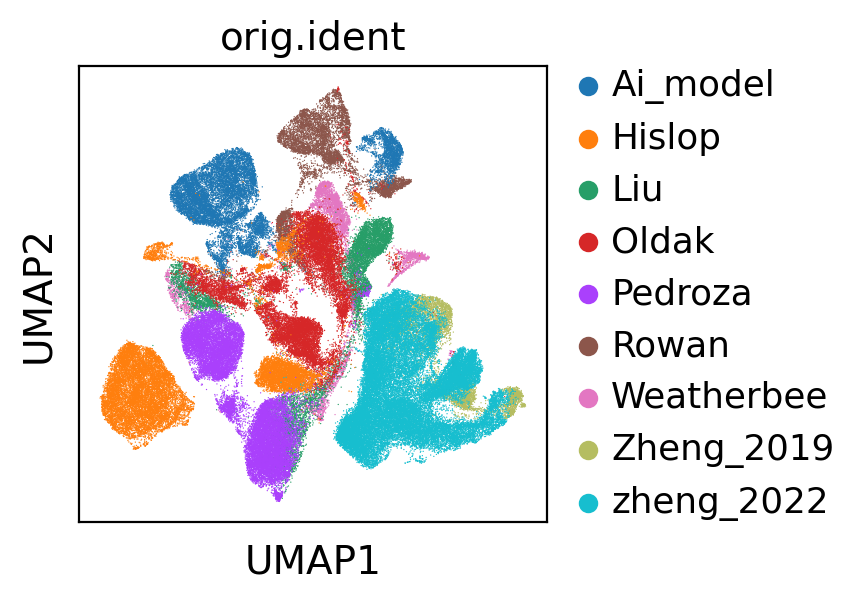

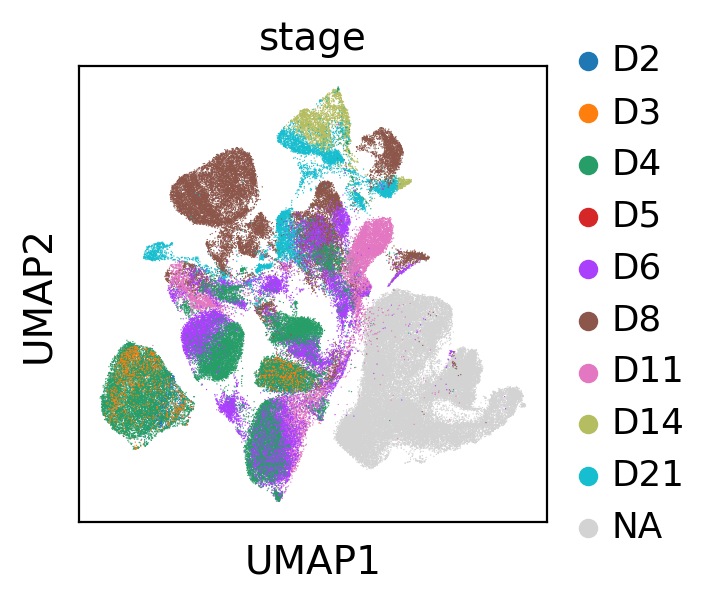

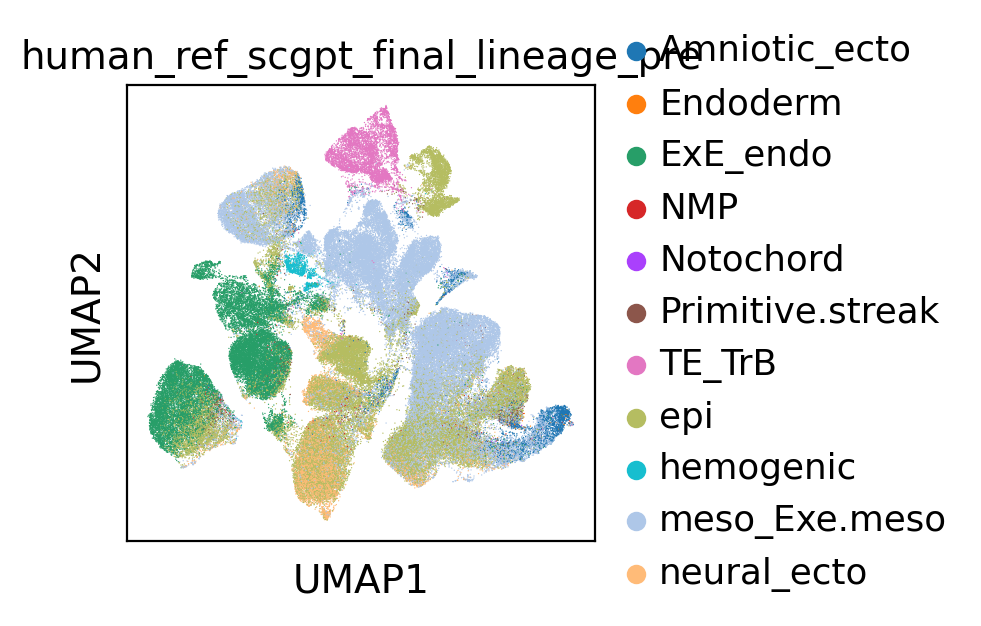

In [15]:
####Unintegrated
combined_adata.obsm["Unintegrated"] = adata_hvg.obsm["X_pca"]
adata_hvg.obsm["Unintegrated"] = adata_hvg.obsm["X_pca"]
sc.pp.neighbors(combined_adata, use_rep="Unintegrated",random_state=42)
sc.tl.leiden(combined_adata, resolution=0.5,key_added=f"Unintegrated_res_0.5",random_state=42)
sc.tl.umap(combined_adata,random_state=42)
combined_adata.obsm['X_Unintegrated'] = combined_adata.obsm['X_umap']
sc.pl.umap(combined_adata, color=['orig.ident'], save="Unintegrated_orig_ident.pdf")
sc.pl.umap(combined_adata, color=['stage'], save="Unintegrated_stage.pdf")
sc.pl.umap(combined_adata, color=['human_ref_scgpt_final_lineage_pre'], save="human_ref_scgpt_final_lineage_pre.pdf")

In [16]:
###scVI
scvi.model.SCVI.setup_anndata(adata_hvg, layer="counts", batch_key="orig.ident")
vae = scvi.model.SCVI(adata_hvg, gene_likelihood="nb", n_layers=2, n_latent=30)
vae.train()

No GPU/TPU found, falling back to CPU. (Set TF_CPP_MIN_LOG_LEVEL=0 and rerun for more info.)
GPU available: False, used: False
TPU available: False, using: 0 TPU cores
IPU available: False, using: 0 IPUs
HPU available: False, using: 0 HPUs


Epoch 58/58: 100%|██████████| 58/58 [15:08<00:00, 15.50s/it, loss=1.02e+03, v_num=1]

`Trainer.fit` stopped: `max_epochs=58` reached.


Epoch 58/58: 100%|██████████| 58/58 [15:08<00:00, 15.67s/it, loss=1.02e+03, v_num=1]


In [17]:
combined_adata.obsm["scVI"] = vae.get_latent_representation()

In [18]:
###scANVI
lvae = scvi.model.SCANVI.from_scvi_model(
    vae,
    adata=adata_hvg,
    labels_key="human_ref_scgpt_final_lineage_pre",
    unlabeled_category="Unknown",
)
lvae.train(max_epochs=20, n_samples_per_label=100)

INFO     Training for 20 epochs.                                                                                   


GPU available: False, used: False
TPU available: False, using: 0 TPU cores
IPU available: False, using: 0 IPUs
HPU available: False, using: 0 HPUs


Epoch 20/20: 100%|██████████| 20/20 [10:16<00:00, 30.81s/it, loss=1.1e+03, v_num=1] 

`Trainer.fit` stopped: `max_epochs=20` reached.


Epoch 20/20: 100%|██████████| 20/20 [10:16<00:00, 30.82s/it, loss=1.1e+03, v_num=1]


In [19]:
combined_adata.obsm["scANVI"] = lvae.get_latent_representation()

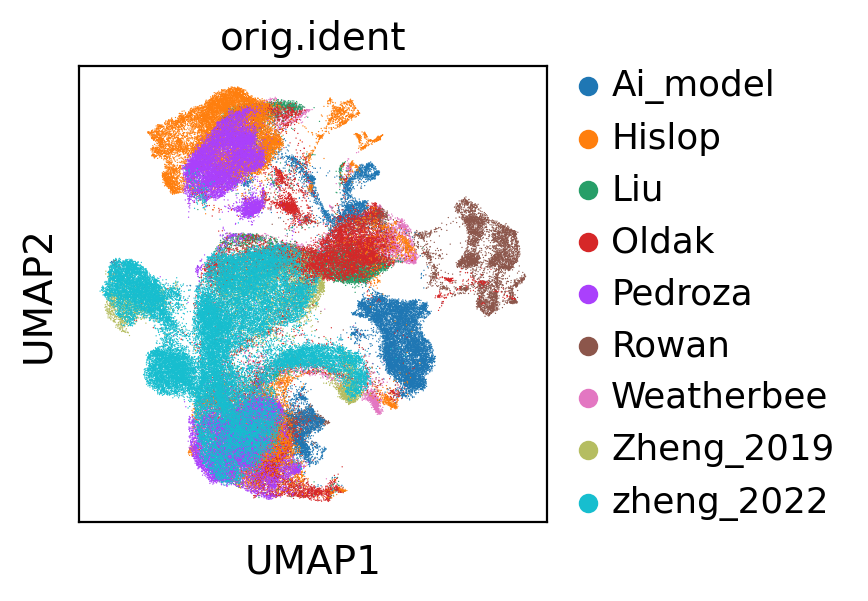

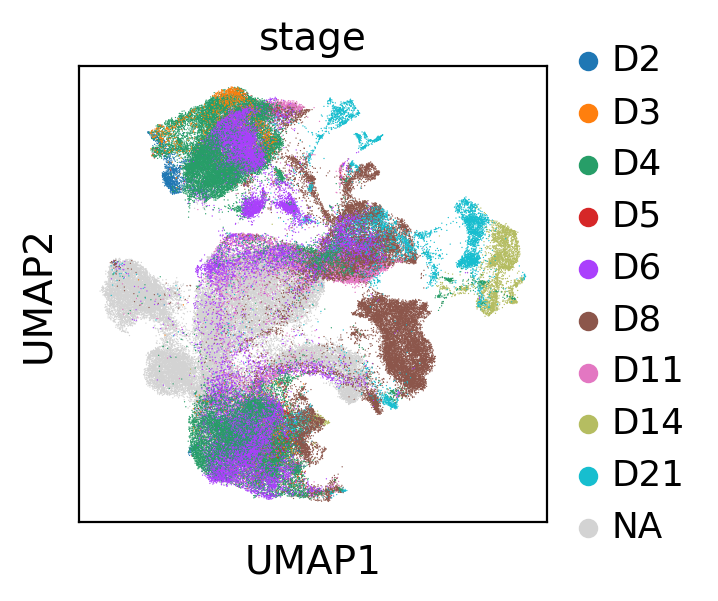

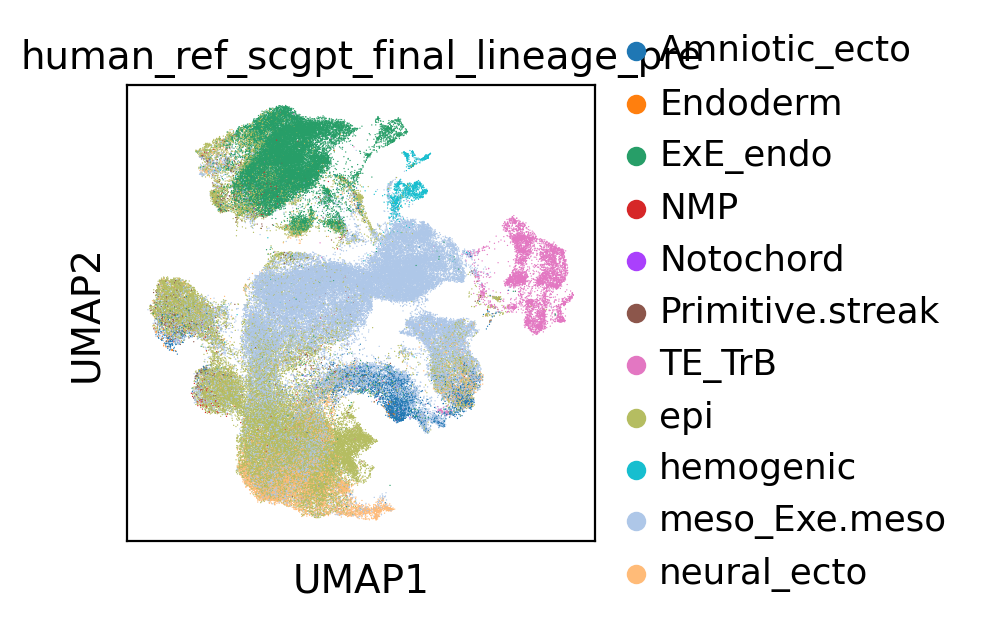

In [20]:
adata_hvg.obsm["scANVI"] = combined_adata.obsm["scANVI"]
sc.pp.neighbors(combined_adata, use_rep="scANVI",random_state=42)
sc.tl.leiden(combined_adata, resolution=0.5,key_added=f"scANVI_res_0.5",random_state=42)
sc.tl.umap(combined_adata,random_state=42)
combined_adata.obsm['X_scANVI'] = combined_adata.obsm['X_umap']
adata_hvg.obsm['X_scANVI'] = combined_adata.obsm['X_scANVI']
sc.pl.umap(combined_adata, color=['orig.ident'],save="scgpt_orig.ident.pdf")
sc.pl.umap(combined_adata, color=['stage'],save="scgpt_stage.pdf")
sc.pl.umap(combined_adata, color=['human_ref_scgpt_final_lineage_pre'],save="scarches_human_ref_scgpt_final_lineage_pre.pdf")

In [21]:
# Check current working directory
print("Current working directory:", os.getcwd())

Current working directory: /storage2/liuxiaodongLab/fanxueying/embryo_benchmarking_rebuttal/code/20250812_label_transfer_integration_label_transfer_quantification


In [ ]:
# Define the list of genes you want to plot
genes_to_plot = ["POU5F1","NANOG",#epiblast
                 "SOX2", "TTYH1", #Neural_ectoderm
                 "GATA3","TFAP2A",
                 "TBXT",  "CDX1","PDGFRA","APOA2","FOXA2","NANOS3",
                "PECAM1","HBZ","PTPRC",
                "GABRP","HEY1","COL6A1","COL6A2",]  # Replace "GENE2" and "GENE3" with the actual gene names

# Plot the UMAP embedding for the specified genes
sc.pl.embedding(
    combined_adata,
    basis='X_umap',
    color=genes_to_plot,
    use_raw=False,
    cmap=sns.cubehelix_palette(dark=0, light=.9, as_cmap=True)
)

In [23]:
combined_adata.raw.var.rename(columns={'_index': 'index'}, inplace=True)
combined_adata.write_h5ad(filename="embryo_model_integration_scgpt.h5ad")